# 01 · Bike-Sharing — Advanced EDA

## Part 1 — Advanced EDA (Bike-Sharing demand)

The same battery of techniques as a financial series, but now the story is about **human rhythms
and weather**: when do people ride, and what conditions drive demand? We cover distributions,
the leakage trap, the daily/weekly/seasonal rhythms, weather drivers, categorical association,
outliers, and missingness.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.clean()
print('rows:', len(df))

setup ok | numpy 2.1.3 | pandas 2.3.3
rows: 17379


### 1. The target `cnt` — a right-skewed count

Rental counts are non-negative and right-skewed (many quiet hours, a few very busy ones). The
four-view battery shows the shape; a **√ transform** tames the skew (the count analogue of the
log we used for prices).

n                  17379.00
mean                 189.46
std                  181.39
skew                   1.28
excess_kurtosis        1.42
min                    1.00
median               142.00
max                  977.00


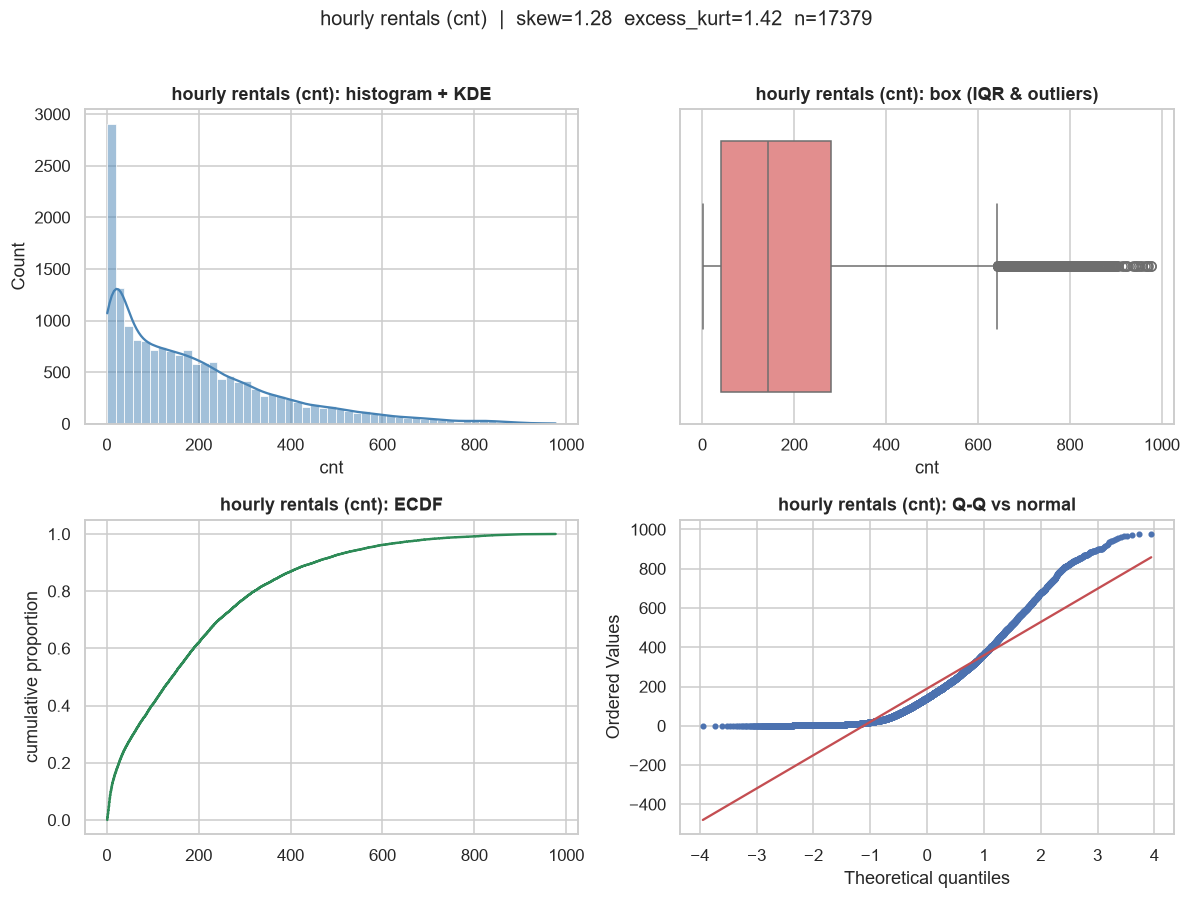

In [2]:
print(eda.moments(df["cnt"]).round(2).to_string())
fig = eda.four_view(df["cnt"], "hourly rentals (cnt)", "p1_fourview_cnt.png"); plt.show()

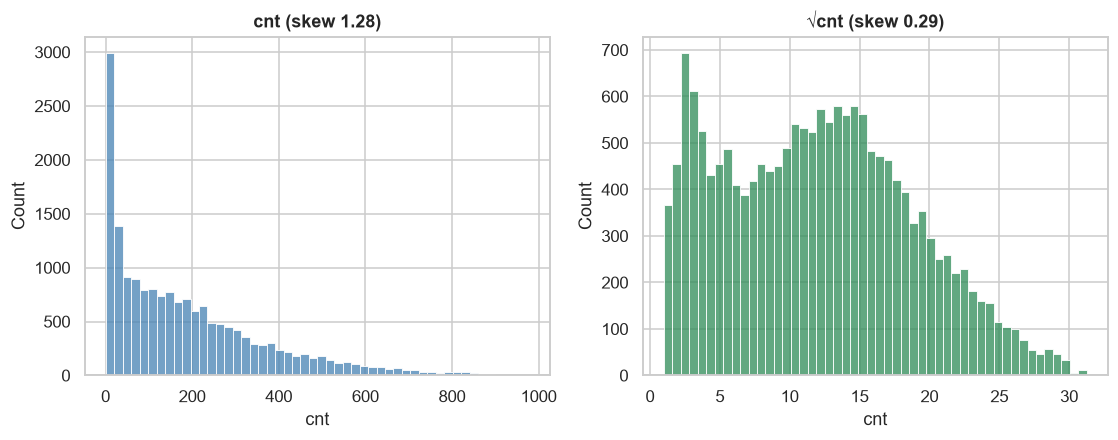

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["cnt"], bins=50, ax=ax[0], color="steelblue"); ax[0].set_title(f"cnt (skew {df.cnt.skew():.2f})")
sns.histplot(np.sqrt(df["cnt"]), bins=50, ax=ax[1], color="seagreen"); ax[1].set_title(f"√cnt (skew {np.sqrt(df.cnt).skew():.2f})")
eda.savefig(fig, "p1_sqrt_transform.png"); plt.show()

### 2. The leakage trap, visualised

`cnt = casual + registered`, so those two columns *are* the answer. Including them would give a
"perfect" model that knows nothing useful. This is the cardinal modelling sin — exclude them.

In [4]:
print("corr(casual, cnt) = %.3f | corr(registered, cnt) = %.3f  (registered dominates demand)"
      % (df.casual.corr(df.cnt), df.registered.corr(df.cnt)))
print("casual+registered exactly reconstruct cnt:", bool((df.casual+df.registered == df.cnt).all()))

corr(casual, cnt) = 0.695 | corr(registered, cnt) = 0.972  (registered dominates demand)
casual+registered exactly reconstruct cnt: True


### 3. Demand rhythms — the heart of this dataset

**Hour of day** reveals commuting: peaks at 8am and 5–6pm. But the single most important EDA plot
here splits that profile by **working day** — the same average hides two completely different
shapes (a Simpson's-paradox-style trap):

- **working days**: sharp twin commute peaks (8am, 5–6pm),
- **weekends/holidays**: a single midday leisure hump.

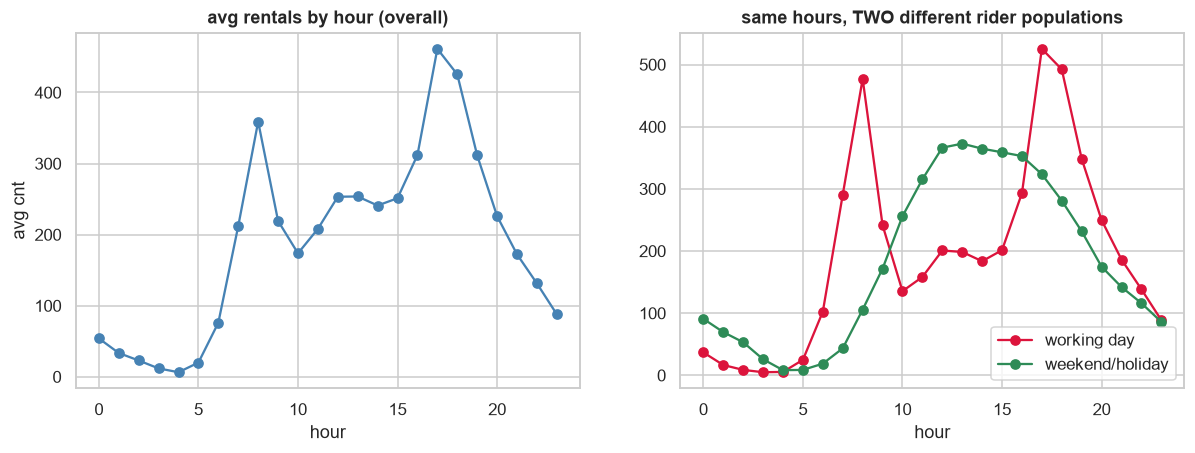

working-day avg 193 vs non-working 181 (close!) — but the SHAPES are opposite.


In [5]:
by_hour = df.groupby("hr", observed=True).cnt.mean()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(by_hour.index, by_hour.values, "o-", color="steelblue"); ax[0].set_title("avg rentals by hour (overall)")
ax[0].set_xlabel("hour"); ax[0].set_ylabel("avg cnt")
split = df.groupby(["workingday","hr"], observed=True).cnt.mean().unstack(0)
ax[1].plot(split.index, split[1], "o-", label="working day", color="crimson")
ax[1].plot(split.index, split[0], "o-", label="weekend/holiday", color="seagreen")
ax[1].set_title("same hours, TWO different rider populations"); ax[1].set_xlabel("hour"); ax[1].legend()
eda.savefig(fig, "p1_hour_profiles.png"); plt.show()
print("working-day avg %.0f vs non-working %.0f (close!) — but the SHAPES are opposite."
      % (df[df.workingday==1].cnt.mean(), df[df.workingday==0].cnt.mean()))

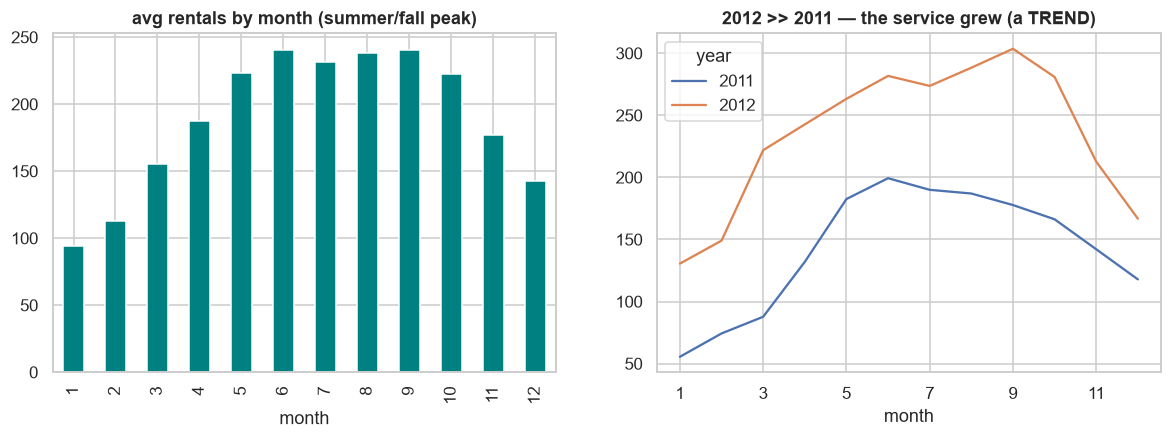

YoY growth: 144 -> 235 (+63%)


In [6]:
# Seasonal + yearly growth
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("mnth", observed=True).cnt.mean().plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("avg rentals by month (summer/fall peak)"); ax[0].set_xlabel("month")
df.groupby(["year","mnth"], observed=True).cnt.mean().unstack(0).plot(ax=ax[1])
ax[1].set_title("2012 >> 2011 — the service grew (a TREND)"); ax[1].set_xlabel("month")
eda.savefig(fig, "p1_seasonality.png"); plt.show()
g = df.groupby("year").cnt.mean(); print("YoY growth: %.0f -> %.0f (+%.0f%%)" % (g[2011], g[2012], 100*(g[2012]/g[2011]-1)))

### 4. Weather drivers + the temp/atemp collinearity

Warmth lifts demand; humidity and wind suppress it. But `temp` and `atemp` ("feels-like")
measure almost the same thing — a textbook **multicollinearity** case (VIF ≈ 44), so you'd keep
only one in a model.

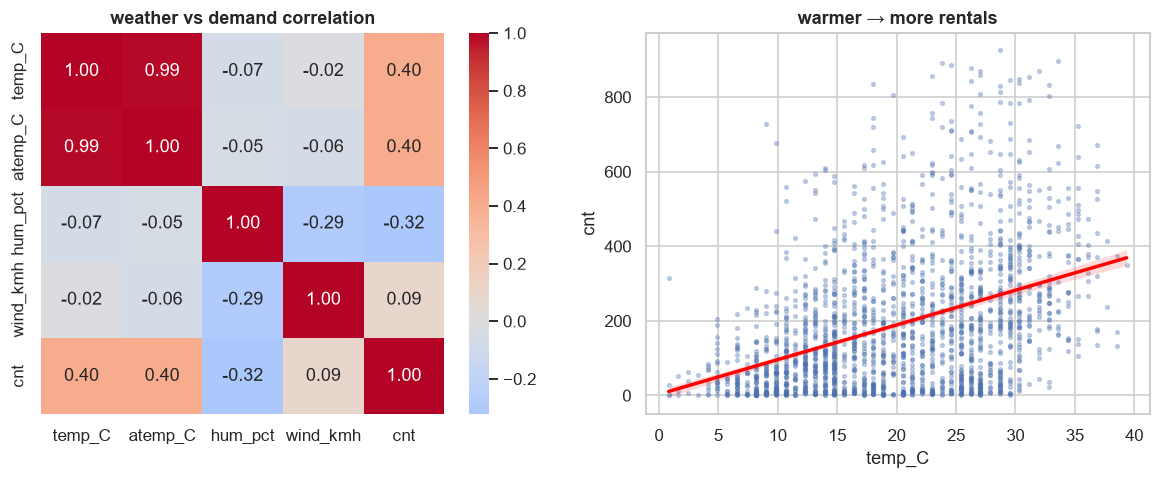

 feature  VIF
 atemp_C 43.7
  temp_C 43.6
wind_kmh  1.2
 hum_pct  1.1
-> temp & atemp are near-duplicates (VIF ~44); keep one.


In [7]:
num = df[["temp_C","atemp_C","hum_pct","wind_kmh","cnt"]]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0]); ax[0].set_title("weather vs demand correlation")
sns.regplot(x="temp_C", y="cnt", data=df.sample(2000, random_state=0), scatter_kws=dict(s=6, alpha=.3), line_kws=dict(color="red"), ax=ax[1])
ax[1].set_title("warmer → more rentals"); eda.savefig(fig, "p1_weather.png"); plt.show()
print(eda.vif_table(df[["temp_C","atemp_C","hum_pct","wind_kmh"]]).round(1).to_string(index=False))
print("-> temp & atemp are near-duplicates (VIF ~44); keep one.")

### 5. Categorical association — Cramér's V

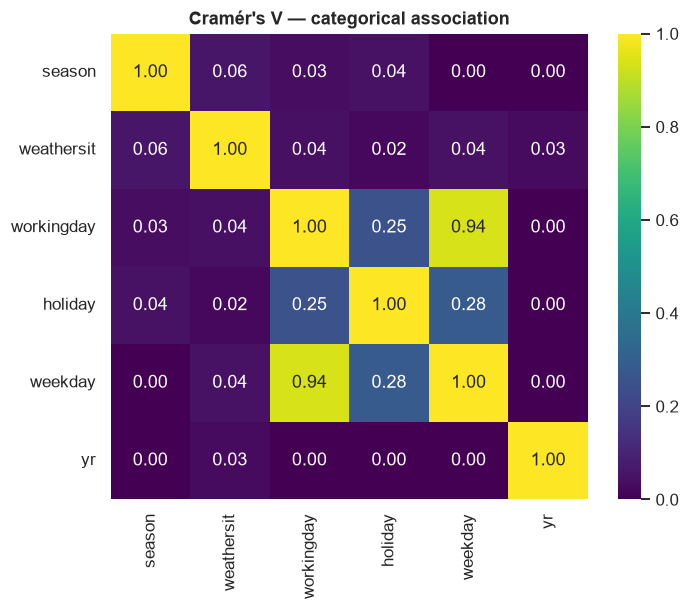

season–weathersit V = 0.06 (weather differs by season); workingday–weekday V = 0.94 (mechanically linked)


In [8]:
cats = ["season","weathersit","workingday","holiday","weekday","yr"]
cv = eda.cramers_v_matrix(df, cats)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cv, annot=True, fmt=".2f", cmap="viridis", ax=ax); ax.set_title("Cramér's V — categorical association")
eda.savefig(fig, "p1_cramers_v.png"); plt.show()
print("season–weathersit V = %.2f (weather differs by season); workingday–weekday V = %.2f (mechanically linked)"
      % (cv.loc["season","weathersit"], cv.loc["workingday","weekday"]))

### 6. Outliers & missingness

Extreme-demand hours are real events (perfect-weather commute peaks), not errors. And unlike
Telco/Shiller, the *values* have **no missing data** — but the *time axis* does (165 absent hours),
which is the kind of gap Part 2's index hygiene must handle.

In [9]:
print(eda.outlier_flags(df["cnt"]).round(1).to_string(index=False))
busiest = df.nlargest(5, "cnt")[["cnt","season_name","weather_name","temp_C","workingday"]]
print("\nBusiest hours (all clear-weather commute times):"); print(busiest.to_string())
print("\nmissing values:", int(df.isna().sum().sum()), "| missing hourly slots:", data.missing_hours(df))

              method  n_flagged  pct
          IQR (1.5x)        505  2.9
Modified z (MAD>3.5)        267  1.5

Busiest hours (all clear-weather commute times):
                     cnt season_name weather_name  temp_C workingday
datetime                                                            
2012-09-12 18:00:00  977        fall        clear   27.06          1
2012-09-20 17:00:00  976        fall        clear   26.24          1
2012-09-11 17:00:00  970        fall        clear   28.70          1
2012-09-10 18:00:00  968        fall        clear   25.42          1
2012-09-25 17:00:00  967      winter        clear   27.06          1

missing values: 0 | missing hourly slots: 165


### Takeaways

- `cnt` is a **right-skewed count**; a √ transform stabilises it. Distributions, not point summaries.
- **`cnt = casual + registered`** is a leakage trap — drop those two from any predictor set.
- Demand is driven by **human rhythms**: a commute double-peak on working days vs a midday hump on
  weekends — the *same* average hiding two populations (always segment before trusting an average).
- Strong **yearly growth (+63%)** and **seasonal/weather** effects → a trend + multi-seasonal series.
- **temp ≈ atemp** (VIF ≈ 44): classic multicollinearity — keep one.
- No missing *values*, but **165 missing hourly slots** — the time axis needs care (Part 2).

**Next — Part 2 (Time-Series Foundations):** a proper hourly index, **multiple seasonalities**
(daily/weekly/yearly), STL/MSTL decomposition, stationarity, and ACF/PACF on the demand series.